In [1]:
import scipy.optimize as optimize
import numpy as np
import zfit
import pandas as pd  
from pandas import Series, DataFrame 
import uproot 
from scipy import stats
from scipy.optimize import curve_fit
from scipy.special import comb
from scipy.stats import chi2
from scipy.special import comb
from scipy.optimize import lsq_linear
import sys
from plot_tools import *
from customStats import *
#import tools
import common_tools
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
# from selection_cuts import selection_nominal
import mplhep as hep
from sklearn.model_selection import train_test_split
plt.style.use(hep.style.CMS)
plt.rcParams['figure.figsize'] = [10,8]
plt.rcParams['font.size'] = 24
plt.figure()
plt.close()
plt.rcParams.update({'figure.figsize':[10,8]})
plt.rcParams.update({'font.size':24})
import tensorflow as tf
import math
import zfit
from zfit import z
import xgboost as xgb
from scipy.interpolate import make_interp_spline
# from loadCutXGB import load_and_cutXGBclfs
from scipy.special import comb
from scipy.optimize import lsq_linear
zfit.settings.set_verbosity(0)
import json
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Oculta los mensajes de INFO y WARNING
from PDFs import *
from scipy.optimize import NonlinearConstraint
from utils_efficiency import *
from utils_fits import *

/home/ghcp/miniconda3/envs/haza_wokr_env/lib/python3.8/site-packages/zfit/__init__.py:63: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
import uproot
import pandas as pd

# --- RUTAS DE ARCHIVOS ---
f_gen = "/home/ghcp/Documentos/CINVESTAV/ANALISYS_B0tomumuKstar/angular/efficiencies/datasets/GenLevel_Angular_Merged.root"
f_gen_filtered = "/home/ghcp/Documentos/CINVESTAV/ANALISYS_B0tomumuKstar/angular/efficiencies/datasets/GenLevel_Angular_Merged_Filtered.root"
f_reco_gen = "/home/ghcp/Documentos/CINVESTAV/ANALISYS_B0tomumuKstar/angular/efficiencies/datasets/RecoGenV2_Angular_Merged.root"  
x_gboost_cut = "/home/ghcp/Documentos/CINVESTAV/ANALISYS_B0tomumuKstar/BdtoK0smumu-20251110T171511Z-1-001/MyReweiting/ResultsB0_2022/AntiRadVeto_MC_NoRes_2022_Era1_v0_XGBoost_fom_cut_BDT.root"

vars_gen_to_load = ["gen_cosThetaK", "gen_cosThetaL", "gen_phi", "q2Gen"]
vars_reco_to_load = ["CosThetaK_best", "CosThetaL_best", "Phi_best", "massJ"] 
vars_xgboost_to_load = ["CosThetaK", "CosThetaL", "Phi", "massB_test", "massJ", "TotalWeight"] 

# --- CARGA DE DATOS ---
#Gen NO filt
genNFtr = uproot.open(f_gen)['ntuple'].arrays(vars_gen_to_load, library='pd')
print(f"1. Gen Non-Filtered (genNFtr) cargado: {len(genNFtr)} eventos")
# Gen Filtered
genFtr = uproot.open(f_gen_filtered)['ntuple'].arrays(vars_gen_to_load, library='pd')
print(f"2. Gen Filtered (genFtr) cargado: {len(genFtr)} eventos")
# Reco Gen Level
recoGen = uproot.open(f_reco_gen)['ntuple'].arrays(vars_reco_to_load, library='pd')
print(f"3. Reco Gen Level Denom (recoGen) cargado: {len(recoGen)} eventos")
# Final selection 
recoFtr = uproot.open(x_gboost_cut)['treeBd'].arrays(vars_xgboost_to_load, library='pd')
print(f"4. Reco Final (recoFtr) cargado: {len(recoFtr)} eventos")


recoFtr["q2"] = recoFtr["massJ"]**2 
recoGen["q2Gen"] = recoGen["massJ"]**2  

GenNFlt = genNFtr.copy()     
GenFlt  = genFtr.copy()       

RecoGenFlt = recoGen.copy()             
mask_mass = (recoFtr["massB_test"] > 5.0) & (recoFtr["massB_test"] < 5.6)
Reco = recoFtr[mask_mass].copy()
#2
eff_Gen, obs_Gen = train_test_split(GenNFlt, test_size=0.03, random_state=549)
eff_GenFtr, obs_GenFtr = train_test_split(GenFlt, test_size=0.1, random_state=2)
eff_RecoGenFtr, obs_RecoGenFtr = train_test_split(RecoGenFlt, test_size=0.1, random_state=2)
eff_RecoFtr, obs_RecoFtr = train_test_split(Reco, test_size=0.1, random_state=22)

a1 = np.array(obs_Gen["gen_cosThetaL"])
a2 = np.array(obs_Gen["gen_cosThetaK"])
a3 = np.array(obs_Gen["gen_phi"])

angles = np.array([a1, a2, a3])
valid_observations_mask = ~np.isnan(angles).any(axis=0)
filtered_data = angles[:, valid_observations_mask]

1. Gen Non-Filtered (genNFtr) cargado: 11589148 eventos
2. Gen Filtered (genFtr) cargado: 307688 eventos
3. Reco Gen Level Denom (recoGen) cargado: 6298017 eventos
4. Reco Final (recoFtr) cargado: 900424 eventos


In [3]:
print(len(obs_RecoFtr))

90043


# FUNCIONES

In [5]:

def save_phy_results_slsqp(result_scipy, phys_dict, cov_phys, obs_order, bin_n, base_dir="fit_results_slsqp", name="fit_results_phys"):
    """
    Guarda los resultados del fit físico y su matriz de covarianza en formato JSON.
    Adaptado para recibir un objeto OptimizeResult de SciPy en lugar de zfit nativo.
    """
    output_folder = os.path.join(base_dir, f"{bin_n}")
    os.makedirs(output_folder, exist_ok=True)
    output_file = os.path.join(output_folder, f"{name}.json")
    
    params_dict = {}
    
    # Extraemos los errores de la diagonal de la matriz de covarianza
    errors_phys = np.sqrt(np.diag(cov_phys))
    
    for i, obs_name in enumerate(obs_order):
        val = phys_dict.get(obs_name, 0.0)
        sym_err = errors_phys[i]
        
        # Asumimos errores simétricos por la aproximación Hessiana
        params_dict[obs_name] = {
            'value': float(val), 
            'error': float(sym_err), 
            'error_low': float(-sym_err), 
            'error_up': float(sym_err), 
            'error_source': "hessian" 
        }

    cov_list = cov_phys.tolist()
    
    # Mapeo de los atributos de SciPy a tu estándar de zfit
    data_to_save = {
        'bin_index': str(bin_n), 
        'valid': bool(result_scipy.success),       # Equivalente a result_zfit.valid
        'converged': bool(result_scipy.success),   # Equivalente a result_zfit.converged
        'fmin': float(result_scipy.fun),           # Equivalente a result_zfit.fmin
        'status': str(result_scipy.message),       # Equivalente a result_zfit.status
        'parameters': params_dict,
        'covariance': cov_list
    }
    
    with open(output_file, 'w') as f:
        json.dump(data_to_save, f, indent=4)
        
    print(f"[CheckPoint] Resultados físicos guardados en: {output_file}")
    return output_file

def select_q2_bin(df, n_bin, cut):
    q2_bins = dict()
    q2_bins = { "bin0":[1.1,23.0],   "bin1":[1.1, 2.0],"bin2": [2.0, 4.0],"bin3":[4.0, 6.0],
                "bin4":[6.0, 7.0],   "bin5":[7.0, 8.0], "bin6": [8.0, 11.0],"bin7":[11.0, 12.5],
                "bin8":[12.5, 15.0], "bin9":[15.0, 17.0], "bin10":[17.0, 23.0]}
    df_ = df[(df[cut]>=q2_bins[n_bin][0]) & (df[cut] <= q2_bins[n_bin][1])].copy()
    return df_



# def run_fit_slsqp_physical(pdf, data, params_list):

#     nll = zfit.loss.UnbinnedNLL(model=pdf, data=data)    
#     def compute_nll(x):
#         zfit.param.set_values(params_list, x)
#         return float(nll.value())


#     constraints = [
#         # 0 <= FL <= 1 
#         {'type': 'ineq', 'fun': lambda x: x[0]},
#         {'type': 'ineq', 'fun': lambda x: 1.0 - x[0]},
        
#         # |S3| <= 1/2(1 - FL)
#         {'type': 'ineq', 'fun': lambda x: 0.5 * (1.0 - x[0]) - x[1]},
#         {'type': 'ineq', 'fun': lambda x: 0.5 * (1.0 - x[0]) + x[1]},
        
#         # S3^2 + 4/9 AFB^2 + S9^2 <= 1/4(1 - FL)^2
#         {'type': 'ineq', 'fun': lambda x: 0.25 * (1.0 - x[0])**2 - (x[1]**2 + (4.0/9.0)*x[3]**2 + x[2]**2)},
        
#         # 4S4^2 + S7^2 <= FL(1 - FL - 2S3)
#         {'type': 'ineq', 'fun': lambda x: x[0] * (1.0 - x[0] - 2.0*x[1]) - (4.0*x[4]**2 + x[5]**2)},
        
#         # S5^2 + 4S8^2 <= FL(1 - FL + 2S3)
#         {'type': 'ineq', 'fun': lambda x: x[0] * (1.0 - x[0] + 2.0*x[1]) - (x[6]**2 + 4.0*x[7]**2)}

#         # # Restricción del determinante de la matriz de densidad
#         # {'type': 'eq', 'fun': lambda x: (
#         #     0.25 * x[0] * (1.0 - x[0])**2 
#         #     - x[0] * x[1]**2 
#         #     - x[0] * ((4.0/9.0) * x[3]**2 + x[2]**2) 
#         #     - 0.25 * (1.0 - x[0] + 2.0 * x[1]) * (4.0 * x[4]**2 + x[5]**2) 
#         #     - 0.25 * (1.0 - x[0] - 2.0 * x[1]) * (x[6]**2 + 4.0 * x[7]**2) 
#         #     - ((2.0/3.0) * x[3] * (2.0 * x[4] * x[6] + 2.0 * x[5] * x[7]) - x[2] * (4.0 * x[4] * x[7] - x[6] * x[5]))
#         # )}
#     ]

#     # lmites iniciales
#     bounds = [
#         (0.0, 1.0),   # FL
#         (-0.5, 0.5),  # S3
#         (-0.5, 0.5),  # S9
#         (-0.75, 0.75),# AFB
#         (-0.36, 0.36),# S4
#         (-0.70, 0.70),# S7
#         (-0.70, 0.70),# S5
#         (-0.36, 0.36) # S8
#     ]

#     # inicial
    
#     x0 = np.array([p.value().numpy() for p in params_list])
#     result_scipy = optimize.minimize(compute_nll, x0, method='SLSQP', bounds=bounds, constraints=constraints,options={'maxiter': 1000, 'ftol': 1e-6, 'disp': True})
#     zfit.param.set_values(params_list, result_scipy.x)

#     return result_scipy, nll


from scipy.optimize import minimize, NonlinearConstraint
import numpy as np
import zfit

def physical_constraints(x):
    # Unpack variables to read the code easily
    FL, S3, S9, AFB, S4, S7, S5, S8 = x
    
    # These expressions must be >= 0
    c1 = 0.5 * (1.0 - FL) - S3
    c2 = 0.5 * (1.0 - FL) + S3
    c3 = 0.25 * (1.0 - FL)**2 - (S3**2 + (4.0/9.0)*AFB**2 + S9**2)
    c4 = FL * (1.0 - FL - 2.0*S3) - (4.0*S4**2 + S7**2)
    c5 = FL * (1.0 - FL + 2.0*S3) - (S5**2 + 4.0*S8**2)
    
    # Determinant of the density matrix
    # c6 = (
    #     0.25 * FL * (1.0 - FL)**2 
    #     - FL * S3**2 
    #     - FL * ((4.0/9.0) * AFB**2 + S9**2) 
    #     - 0.25 * (1.0 - FL + 2.0 * S3) * (4.0 * S4**2 + S7**2) 
    #     - 0.25 * (1.0 - FL - 2.0 * S3) * (S5**2 + 4.0 * S8**2) 
    #     - ((2.0/3.0) * AFB * (2.0 * S4 * S5 + 2.0 * S7 * S8) - S9 * (4.0 * S4 * S8 - S5 * S7))
    # )
    
    # Return all constraints in one array
    # return np.array([c1, c2, c3, c4, c5, c6])
    return np.array([c1, c2, c3, c4, c5])

def run_fit_slsqp_physical(pdf, data, params_list):
    nll = zfit.loss.UnbinnedNLL(model=pdf, data=data)    
    
    def compute_nll(x):
        # Set the new parameter values
        zfit.param.set_values(params_list, x)
        return float(nll.value())

    # Lower bounds: all elements must be at least 0.0
    #lb = np.zeros(6)
    lb = np.zeros(5)
    # Upper bounds: c1 to c5 can go to infinity, 
    # but c6 (determinant) must be 0.0 to act as an equality constraint.
    # If you decide to make it >= 0 later, just change the last 0.0 to np.inf
    #ub = np.array([np.inf, np.inf, np.inf, np.inf, np.inf, 0.0])
    ub = np.array([np.inf, np.inf, np.inf, np.inf, np.inf])

    # Create the constraint object with arrays
    nlc = NonlinearConstraint(physical_constraints, lb=lb, ub=ub)

    # Initial limits for the fit
    bounds = [
        (0.0, 1.0),   # FL
        (-0.5, 0.5),  # S3
        (-0.5, 0.5),  # S9
        (-0.75, 0.75),# AFB
        (-0.36, 0.36),# S4
        (-0.70, 0.70),# S7
        (-0.70, 0.70),# S5
        (-0.36, 0.36) # S8
    ]
    
    # Get starting values
    x0 = np.array([p.value().numpy() for p in params_list])
    
    # Run the minimization
    result_scipy = minimize(
        compute_nll, 
        x0, 
        method='SLSQP', 
        bounds=bounds, 
        constraints=[nlc], 
        options={'maxiter': 1000, 'ftol': 1e-6, 'disp': True}
    )
    
    # Save the result to zfit parameters
    zfit.param.set_values(params_list, result_scipy.x)
    return result_scipy, nll


def calculate_hessian_errors(nll, params_list):
    hessian_tf = nll.hessian(params=params_list)
    H = hessian_tf.numpy()
    

    V = np.linalg.inv(H)
    variances = np.diagonal(V)
    if np.any(variances < 0):
        print("      [ADVERTENCIA] Varianzas negativas detectadas. El mínimo podría no ser válido.")
        variances = np.abs(variances)
    errors = np.sqrt(variances)
    
    return errors, V
        


# FIT SLSQP GEN LEVEL

In [ ]:
q2_bins = {"bin1": [1.1, 2.0], "bin2": [2.0, 4.0], "bin3": [4.0, 6.0], "bin4": [6.0, 7.0], "bin5": [7.0, 8.0], "bin7": [11.0, 12.5], "bin9": [15.0, 17.0], "bin10": [17.0, 23.0]}

for binN in q2_bins.keys():
    print(f"\n{'='*60}\nProcesando {binN} con rango q2: {q2_bins[binN]}\n{'='*60}")

    # ======================================================
    # CONFIGURACIÓN DEL ESPACIO 
    # ======================================================
    cos_l = zfit.Space('cos_l', limits=(-1, 1))
    cos_k = zfit.Space('cos_k', limits=(-1, 1))
    phi   = zfit.Space('phi',   limits=(-np.pi, np.pi)) 
    obs_ang = cos_l * cos_k * phi  

    # # Parámetros Físicos con límites 
    # FL  = zfit.Parameter(f'FL_{binN}',  0.5, lower_limit=0.0, upper_limit=1.0)
    # S3  = zfit.Parameter(f'S3_{binN}',  0.0, lower_limit=-0.5, upper_limit=0.5)
    # S9  = zfit.Parameter(f'S9_{binN}',  0.0, lower_limit=-0.5, upper_limit=0.5)
    # AFB = zfit.Parameter(f'AFB_{binN}', 0.0, lower_limit=-0.75, upper_limit=0.75)
    # S4  = zfit.Parameter(f'S4_{binN}',  0.0, lower_limit=-0.36, upper_limit=0.36)
    # S7  = zfit.Parameter(f'S7_{binN}',  0.0, lower_limit=-0.70, upper_limit=0.70)
    # S5  = zfit.Parameter(f'S5_{binN}',  0.0, lower_limit=-0.70, upper_limit=0.70)
    # S8  = zfit.Parameter(f'S8_{binN}',  0.0, lower_limit=-0.36, upper_limit=0.36)
    
    # Parámetros Físicos 
    FL  = zfit.Parameter(f'FL_{binN}',  0.5)
    S3  = zfit.Parameter(f'S3_{binN}',  0.0)
    S9  = zfit.Parameter(f'S9_{binN}',  0.0)
    AFB = zfit.Parameter(f'AFB_{binN}', 0.0)
    S4  = zfit.Parameter(f'S4_{binN}',  0.0)
    S7  = zfit.Parameter(f'S7_{binN}',  0.0)
    S5  = zfit.Parameter(f'S5_{binN}',  0.0)
    S8  = zfit.Parameter(f'S8_{binN}',  0.0)
    

    r_keys = ['FL', 'S3', 'S9', 'AFB', 'S4', 'S7', 'S5', 'S8']
    fit_params_list_phy = [FL, S3, S9, AFB, S4, S7, S5, S8]

    # ======================================================
    # CONSTRUCCIÓN DE PDFs Y CARGA DE DATOS
    # ======================================================
    pdf_ang_phy = FullAngular_Physical_PDF(obs_ang, FL, S3, S9, AFB, S4, S7, S5, S8)
    
    obs_Gen_q2 = select_q2_bin(obs_Gen, binN, "q2Gen")
    data_true = zfit.Data.from_numpy(array=obs_Gen_q2[["gen_cosThetaL", "gen_cosThetaK", "gen_phi"]].to_numpy(), obs=obs_ang)

    # ======================================================
    # FITS
    # ======================================================
    print("\n" + "="*60)
    print(">>> INICIANDO FIT GEN LEVEL PHYSICAL PDF (SLSQP) <<<")
    print("="*60)
    result_scipy, nll = run_fit_slsqp_physical(pdf_ang_phy, data_true, fit_params_list_phy)
    print("\nValores  y Errores (Hess):")        
    errores, cov_matrix = calculate_hessian_errors(nll, fit_params_list_phy)
    for param, error in zip(fit_params_list_phy, errores):
        print(f"{param.name}: {param.value().numpy():.4f} ± {error:.4f}")

    # ======================================================
    # GUARDADO DE RESULTADO
    # ======================================================
    base_dir = "fit_results/gen/gen_phy_slsqp"
    out_dir = f"{base_dir}/{binN}"
    os.makedirs(out_dir, exist_ok=True)        
    cov_file = f"{out_dir}/cov_matrix_{binN}.npy"
    np.save(cov_file, cov_matrix)
    
    res_file = f"{out_dir}/fit_results_{binN}.txt"
    with open(res_file, "w") as f:
        f.write("Parameter\tValue\tError\n")
        for param, error in zip(fit_params_list_phy, errores):
            f.write(f"{param.name}\t{param.value().numpy():.6f}\t{error:.6f}\n")

        phys_dict_values = {param.name.split('_')[0]: param.value().numpy() for param in fit_params_list_phy}        
        # Definir el orden estricto de los observables (obs_order)
        r_keys = ['FL', 'S3', 'S9', 'AFB', 'S4', 'S7', 'S5', 'S8']
        save_phy_results_slsqp(result_scipy=result_scipy, phys_dict=phys_dict_values, cov_phys=cov_matrix, obs_order=r_keys, bin_n=binN, base_dir="fit_results/gen/gen_phy_slsqp",name=f"fit_results_gen_physical_slsqp_{binN}")    
        print(f"\n[INFO] Resultados guardados en: {out_dir}")

    


Procesando bin1 con rango q2: [1.1, 2.0]

>>> INICIANDO FIT GEN LEVEL PHYSICAL PDF (SLSQP) <<<
Optimization terminated successfully    (Exit mode 0)
            Current function value: 36538.49394360456
            Iterations: 19
            Function evaluations: 195
            Gradient evaluations: 19

Valores  y Errores (Hess):
FL_bin1: 0.6775 ± 0.0061
S3_bin1: -0.0035 ± 0.0085
S9_bin1: -0.0091 ± 0.0084
AFB_bin1: -0.0072 ± 0.0057
S4_bin1: 0.0145 ± 0.0101
S7_bin1: 0.0085 ± 0.0101
S5_bin1: 0.0058 ± 0.0100
S8_bin1: -0.0207 ± 0.0103
[CheckPoint] Resultados físicos guardados en: fit_results/gen/gen_phy_slsqp/bin1/fit_results_gen_physical_slsqp_bin1.json

[INFO] Resultados guardados en: fit_results/gen/gen_phy_slsqp/bin1

Procesando bin2 con rango q2: [2.0, 4.0]

>>> INICIANDO FIT GEN LEVEL PHYSICAL PDF (SLSQP) <<<
Optimization terminated successfully    (Exit mode 0)
            Current function value: 69692.48083569901
            Iterations: 20
            Function evaluations: 201
  

# FIT SLSQP RECO LEVEL


Procesando bin1 con rango q2: [1.1, 2.0]

>>> INICIANDO FIT RECO LEVEL PHYSICAL PDF (SLSQP) <<<
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7517.539742898516
            Iterations: 16
            Function evaluations: 165
            Gradient evaluations: 16

Valores y Errores (Hess):

------------------------------------------------------------
RESUMEN DE OBSERVABLES FÍSICOS RECO (Bin: bin1)
------------------------------------------------------------
Observable | Valor      | Error     
------------------------------------------------------------
FL         |     0.6620 | ± 0.0138
S3         |     0.0115 | ± 0.0126
S9         |    -0.0062 | ± 0.0130
AFB        |     0.0147 | ± 0.0178
S4         |    -0.0982 | ± 0.0290
S7         |     0.0382 | ± 0.0191
S5         |     0.0023 | ± 0.0195
S8         |    -0.0284 | ± 0.0290
------------------------------------------------------------

[CheckPoint] Resultados físicos guardados en: fit_resul

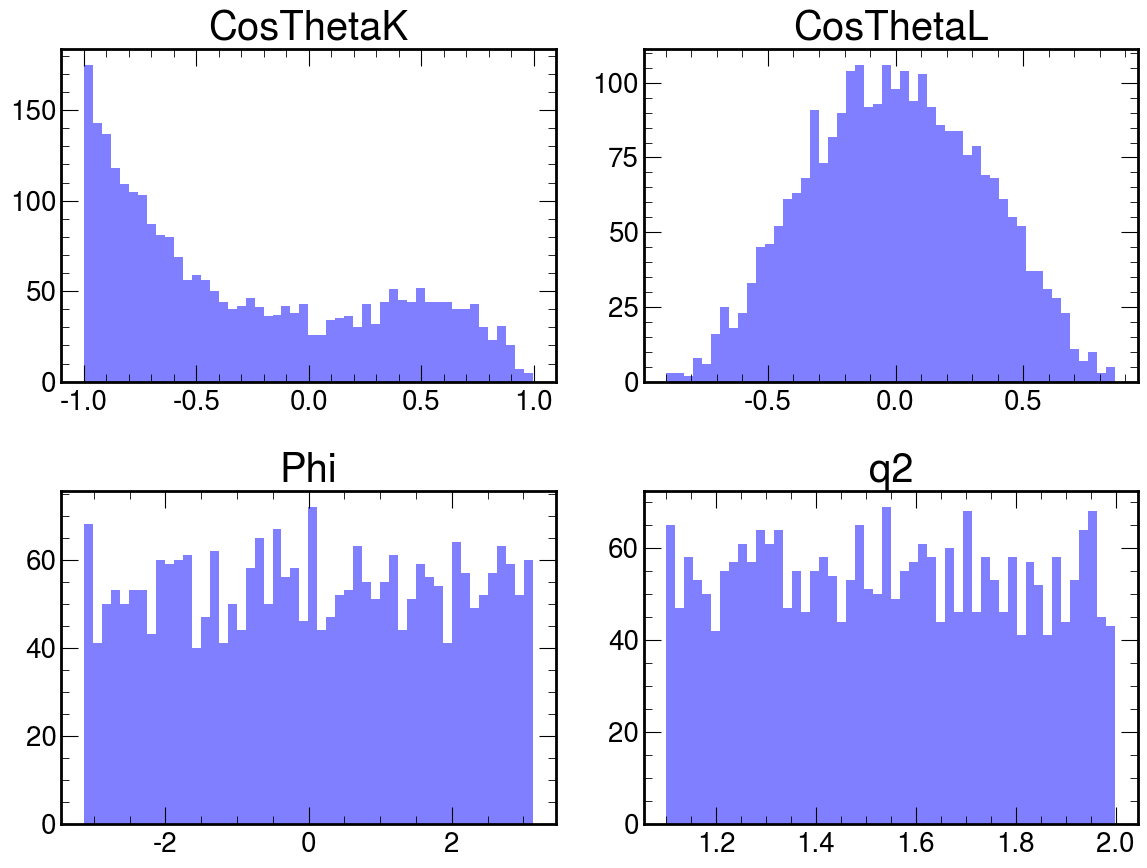


Procesando bin2 con rango q2: [2.0, 4.0]

>>> INICIANDO FIT RECO LEVEL PHYSICAL PDF (SLSQP) <<<
Optimization terminated successfully    (Exit mode 0)
            Current function value: 15558.646020147833
            Iterations: 20
            Function evaluations: 201
            Gradient evaluations: 20

Valores y Errores (Hess):

------------------------------------------------------------
RESUMEN DE OBSERVABLES FÍSICOS RECO (Bin: bin2)
------------------------------------------------------------
Observable | Valor      | Error     
------------------------------------------------------------
FL         |     0.7022 | ± 0.0094
S3         |     0.0082 | ± 0.0090
S9         |     0.0128 | ± 0.0091
AFB        |     0.0084 | ± 0.0107
S4         |    -0.2221 | ± 0.0173
S7         |     0.0181 | ± 0.0135
S5         |     0.0051 | ± 0.0135
S8         |    -0.0305 | ± 0.0178
------------------------------------------------------------

[CheckPoint] Resultados físicos guardados en: fit_resu

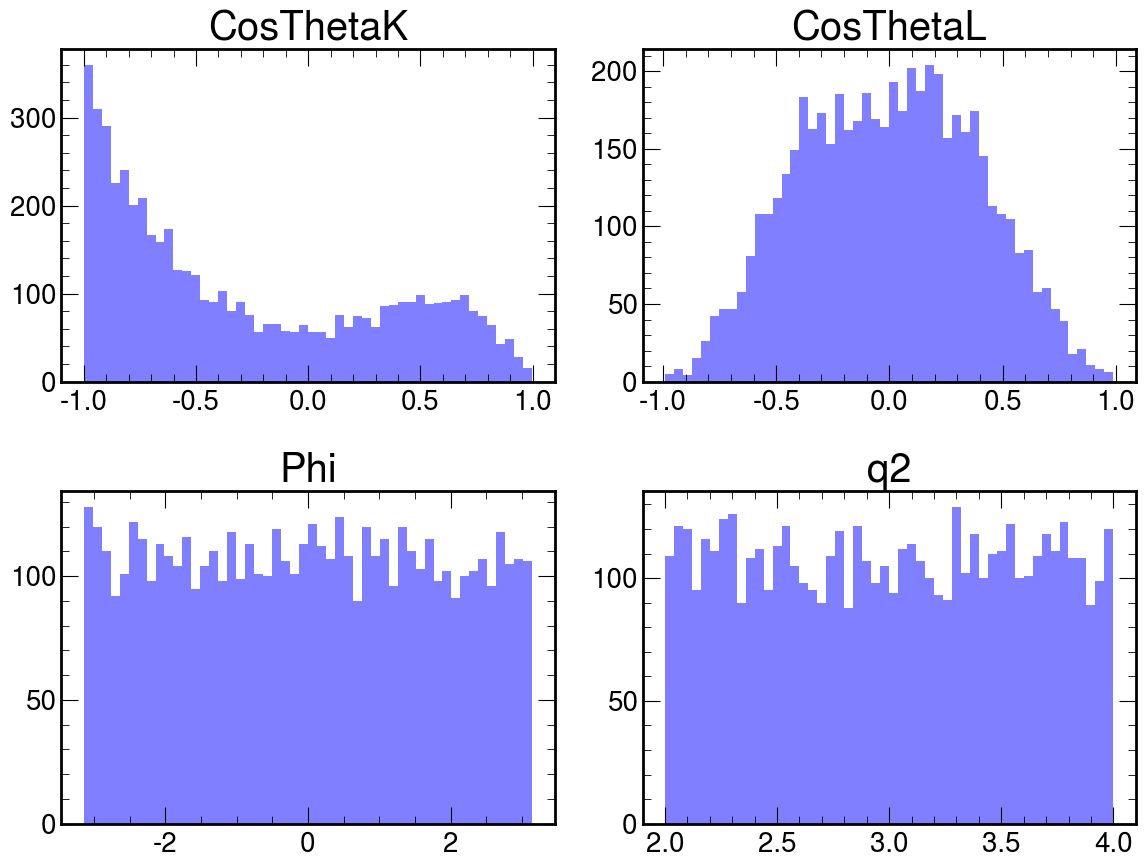


Procesando bin3 con rango q2: [4.0, 6.0]

>>> INICIANDO FIT RECO LEVEL PHYSICAL PDF (SLSQP) <<<
Optimization terminated successfully    (Exit mode 0)
            Current function value: 18710.267828696004
            Iterations: 20
            Function evaluations: 196
            Gradient evaluations: 20

Valores y Errores (Hess):

------------------------------------------------------------
RESUMEN DE OBSERVABLES FÍSICOS RECO (Bin: bin3)
------------------------------------------------------------
Observable | Valor      | Error     
------------------------------------------------------------
FL         |     0.6498 | ± 0.0086
S3         |    -0.0184 | ± 0.0093
S9         |     0.0040 | ± 0.0096
AFB        |     0.0213 | ± 0.0087
S4         |    -0.2506 | ± 0.0140
S7         |     0.0129 | ± 0.0131
S5         |    -0.0049 | ± 0.0126
S8         |    -0.0033 | ± 0.0151
------------------------------------------------------------

[CheckPoint] Resultados físicos guardados en: fit_resu

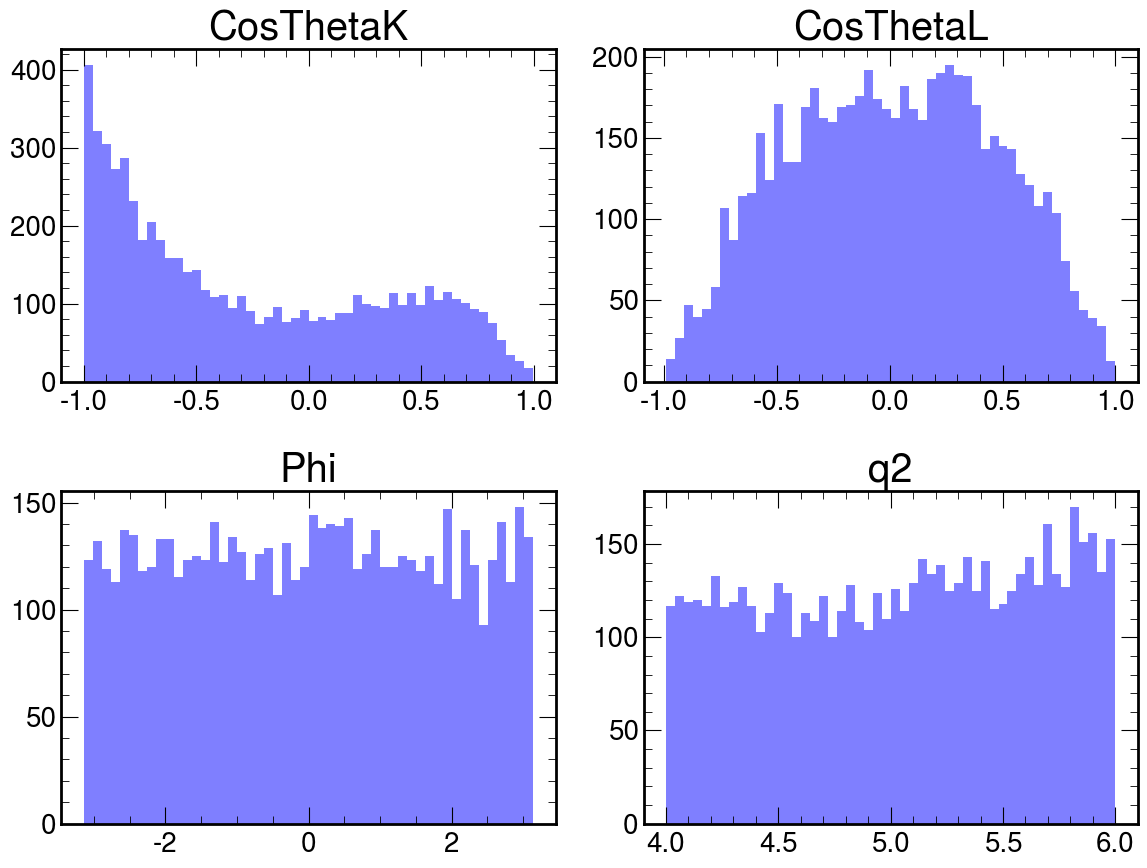


Procesando bin4 con rango q2: [6.0, 7.0]

>>> INICIANDO FIT RECO LEVEL PHYSICAL PDF (SLSQP) <<<
Optimization terminated successfully    (Exit mode 0)
            Current function value: 12264.83477413227
            Iterations: 20
            Function evaluations: 196
            Gradient evaluations: 20

Valores y Errores (Hess):

------------------------------------------------------------
RESUMEN DE OBSERVABLES FÍSICOS RECO (Bin: bin4)
------------------------------------------------------------
Observable | Valor      | Error     
------------------------------------------------------------
FL         |     0.5724 | ± 0.0113
S3         |    -0.0142 | ± 0.0132
S9         |    -0.0070 | ± 0.0134
AFB        |     0.0026 | ± 0.0113
S4         |    -0.2554 | ± 0.0171
S7         |    -0.0047 | ± 0.0166
S5         |     0.0029 | ± 0.0159
S8         |     0.0271 | ± 0.0186
------------------------------------------------------------

[CheckPoint] Resultados físicos guardados en: fit_resul

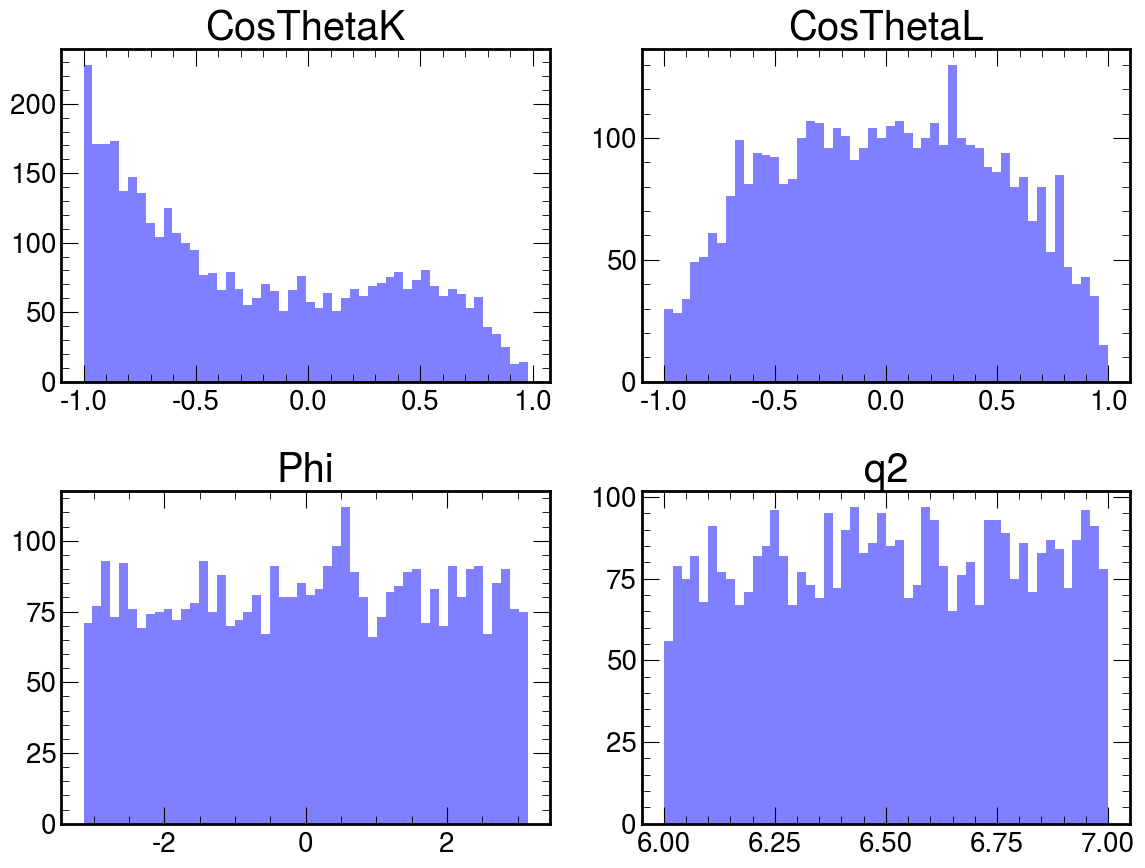


Procesando bin5 con rango q2: [7.0, 8.0]

>>> INICIANDO FIT RECO LEVEL PHYSICAL PDF (SLSQP) <<<
Optimization terminated successfully    (Exit mode 0)
            Current function value: 13582.713361078242
            Iterations: 19
            Function evaluations: 186
            Gradient evaluations: 19

Valores y Errores (Hess):

------------------------------------------------------------
RESUMEN DE OBSERVABLES FÍSICOS RECO (Bin: bin5)
------------------------------------------------------------
Observable | Valor      | Error     
------------------------------------------------------------
FL         |     0.5314 | ± 0.0109
S3         |    -0.0448 | ± 0.0138
S9         |     0.0117 | ± 0.0137
AFB        |    -0.0067 | ± 0.0107
S4         |    -0.2723 | ± 0.0158
S7         |    -0.0067 | ± 0.0163
S5         |     0.0302 | ± 0.0152
S8         |    -0.0104 | ± 0.0171
------------------------------------------------------------

[CheckPoint] Resultados físicos guardados en: fit_resu

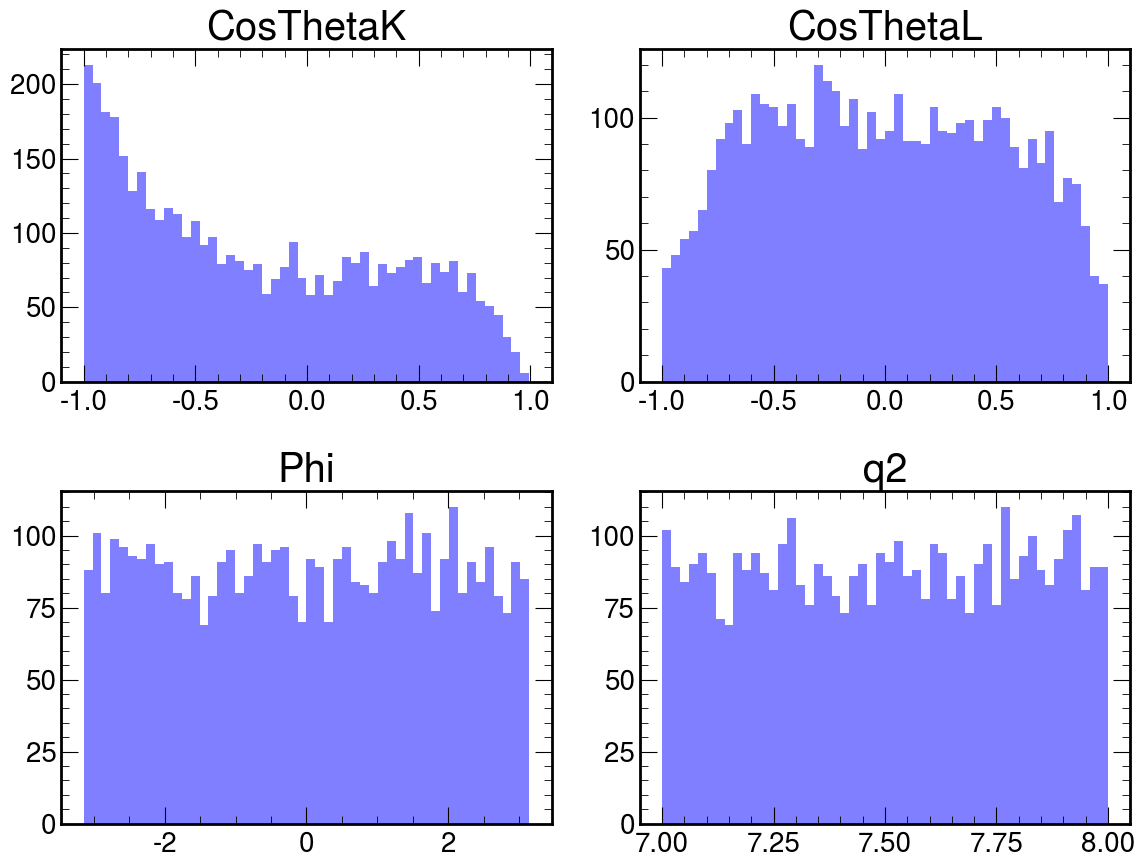


Procesando bin7 con rango q2: [11.0, 12.5]

>>> INICIANDO FIT RECO LEVEL PHYSICAL PDF (SLSQP) <<<
Optimization terminated successfully    (Exit mode 0)
            Current function value: 31085.30153169933
            Iterations: 21
            Function evaluations: 210
            Gradient evaluations: 21

Valores y Errores (Hess):

------------------------------------------------------------
RESUMEN DE OBSERVABLES FÍSICOS RECO (Bin: bin7)
------------------------------------------------------------
Observable | Valor      | Error     
------------------------------------------------------------
FL         |     0.4137 | ± 0.0073
S3         |    -0.0441 | ± 0.0106
S9         |    -0.0115 | ± 0.0107
AFB        |    -0.0158 | ± 0.0072
S4         |    -0.2633 | ± 0.0096
S7         |    -0.0142 | ± 0.0109
S5         |     0.0211 | ± 0.0102
S8         |     0.0235 | ± 0.0109
------------------------------------------------------------

[CheckPoint] Resultados físicos guardados en: fit_res

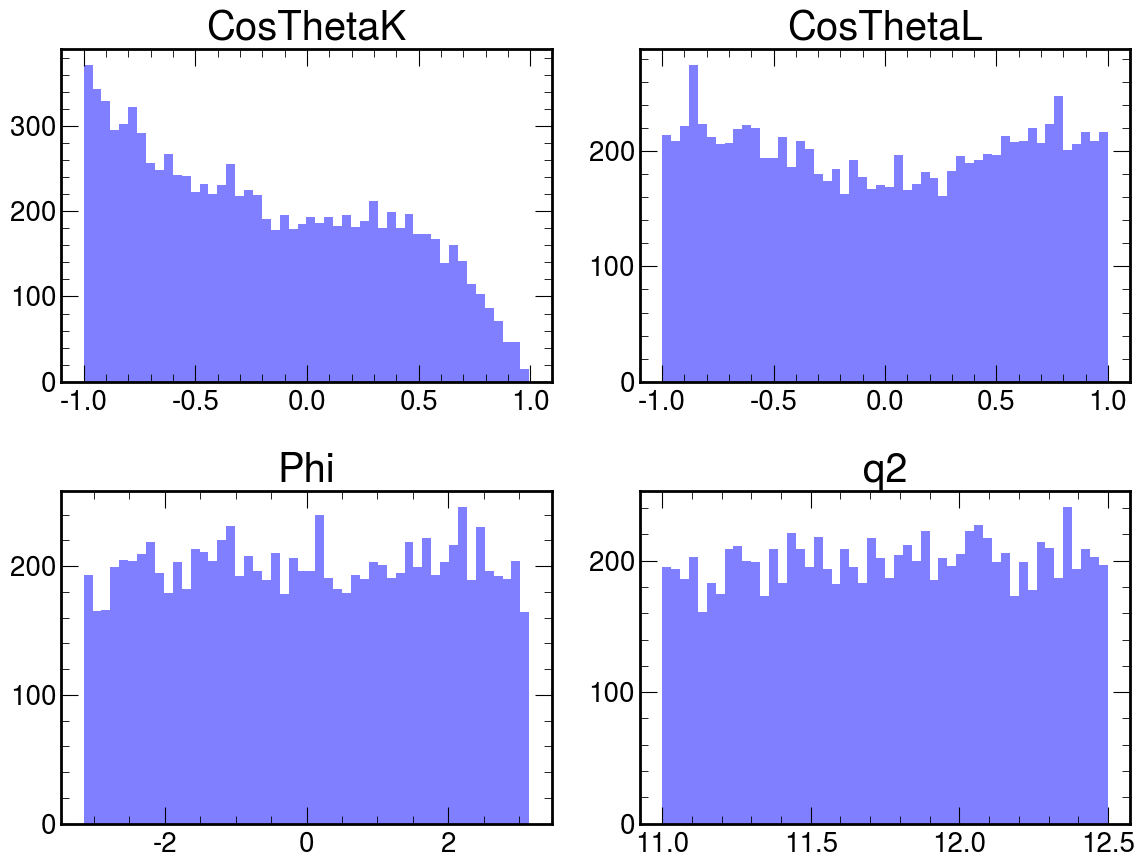


Procesando bin9 con rango q2: [15.0, 17.0]

>>> INICIANDO FIT RECO LEVEL PHYSICAL PDF (SLSQP) <<<
Optimization terminated successfully    (Exit mode 0)
            Current function value: 42691.879085277375
            Iterations: 20
            Function evaluations: 201
            Gradient evaluations: 20

Valores y Errores (Hess):

------------------------------------------------------------
RESUMEN DE OBSERVABLES FÍSICOS RECO (Bin: bin9)
------------------------------------------------------------
Observable | Valor      | Error     
------------------------------------------------------------
FL         |     0.3224 | ± 0.0060
S3         |    -0.0847 | ± 0.0096
S9         |     0.0132 | ± 0.0096
AFB        |     0.0134 | ± 0.0066
S4         |    -0.2365 | ± 0.0086
S7         |     0.0015 | ± 0.0092
S5         |     0.0149 | ± 0.0087
S8         |    -0.0058 | ± 0.0095
------------------------------------------------------------

[CheckPoint] Resultados físicos guardados en: fit_re

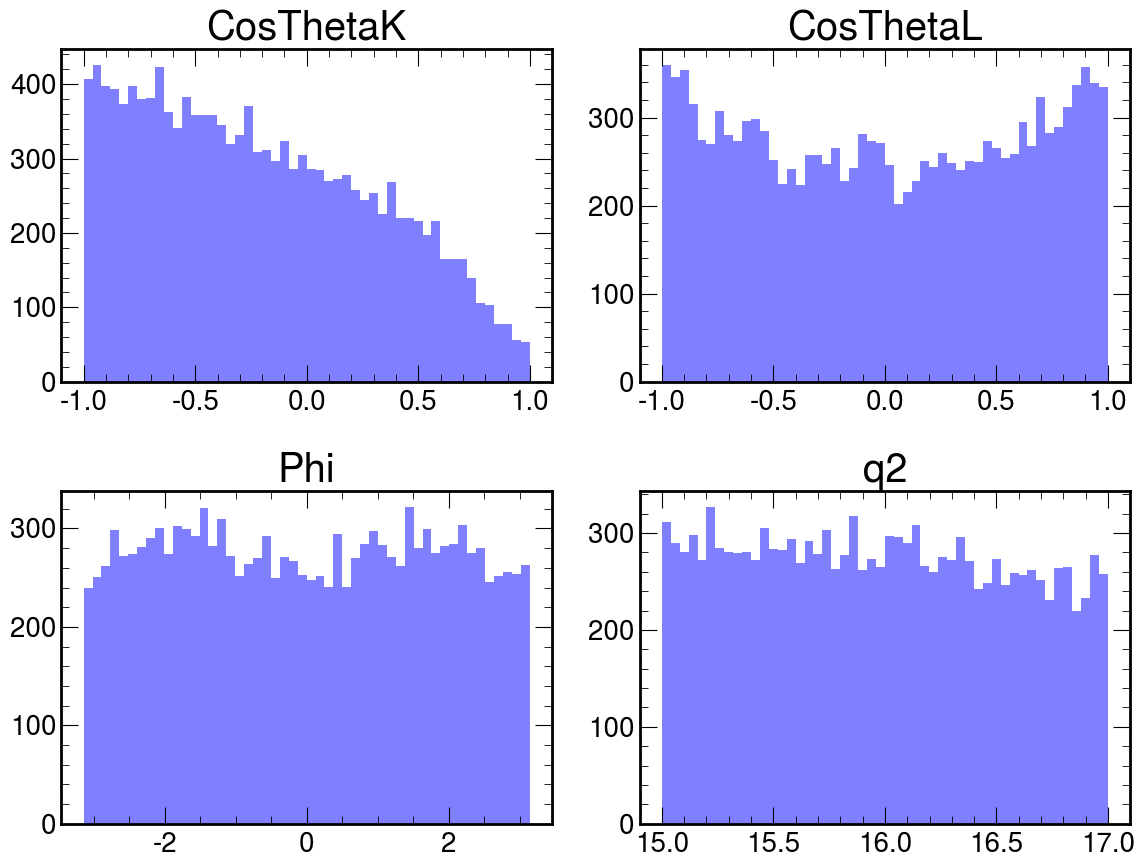


Procesando bin10 con rango q2: [17.0, 23.0]

>>> INICIANDO FIT RECO LEVEL PHYSICAL PDF (SLSQP) <<<
Optimization terminated successfully    (Exit mode 0)
            Current function value: 26350.122735903762
            Iterations: 21
            Function evaluations: 208
            Gradient evaluations: 21

Valores y Errores (Hess):

------------------------------------------------------------
RESUMEN DE OBSERVABLES FÍSICOS RECO (Bin: bin10)
------------------------------------------------------------
Observable | Valor      | Error     
------------------------------------------------------------
FL         |     0.3113 | ± 0.0075
S3         |    -0.1887 | ± 0.0116
S9         |    -0.0323 | ± 0.0118
AFB        |     0.0053 | ± 0.0087
S4         |    -0.2070 | ± 0.0110
S7         |    -0.0053 | ± 0.0119
S5         |    -0.0017 | ± 0.0104
S8         |    -0.0037 | ± 0.0122
------------------------------------------------------------

[CheckPoint] Resultados físicos guardados en: fit_

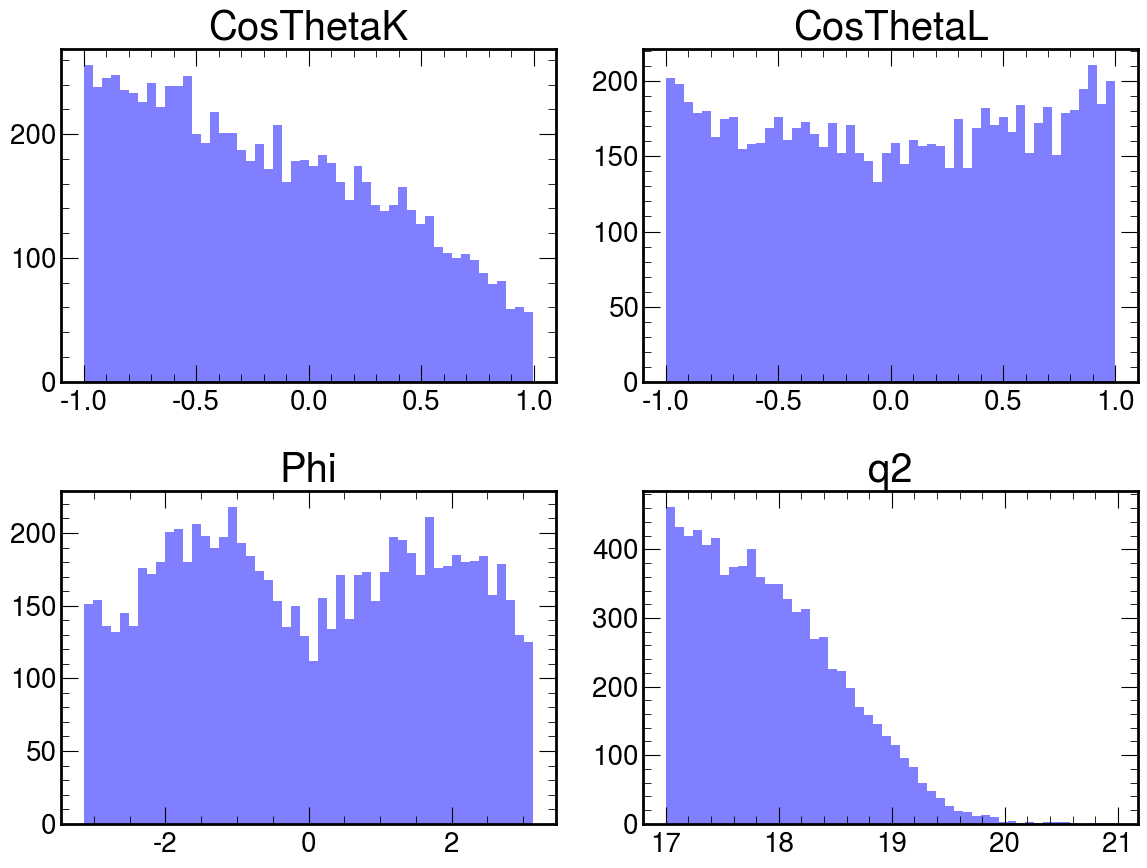

In [6]:


q2_bins = {"bin1": [1.1, 2.0], "bin2": [2.0, 4.0], "bin3": [4.0, 6.0], "bin4": [6.0, 7.0], "bin5": [7.0, 8.0], "bin7": [11.0, 12.5], "bin9": [15.0, 17.0], "bin10": [17.0, 23.0]}
# q2_bins = {"bin1": [1.1, 2.0]} # Expandir según sea necesario

for binN in q2_bins.keys():
    print(f"\n{'='*60}\nProcesando {binN} con rango q2: {q2_bins[binN]}\n{'='*60}")

    # ======================================================
    # CONFIGURACIÓN DEL ESPACIO 
    # ======================================================
    cos_l = zfit.Space('cos_l', limits=(-1, 1))
    cos_k = zfit.Space('cos_k', limits=(-1, 1))
    phi   = zfit.Space('phi',   limits=(-np.pi, np.pi)) 
    obs_ang = cos_l * cos_k * phi  

    # ======================================================
    # PARÁMETROS FÍSICOS (Límites físicos estrictos para SLSQP)
    # ======================================================
    # Recomiendo activar los límites si tu wrapper de SLSQP los pasa a scipy.optimize
    FL  = zfit.Parameter(f'FL_{binN}_reco',  0.5, lower_limit=0.0, upper_limit=1.0)
    S3  = zfit.Parameter(f'S3_{binN}_reco',  0.0, lower_limit=-0.5, upper_limit=0.5)
    S9  = zfit.Parameter(f'S9_{binN}_reco',  0.0, lower_limit=-0.5, upper_limit=0.5)
    AFB = zfit.Parameter(f'AFB_{binN}_reco', 0.0, lower_limit=-0.75, upper_limit=0.75)
    S4  = zfit.Parameter(f'S4_{binN}_reco',  0.0, lower_limit=-0.36, upper_limit=0.36)
    S7  = zfit.Parameter(f'S7_{binN}_reco',  0.0, lower_limit=-0.70, upper_limit=0.70)
    S5  = zfit.Parameter(f'S5_{binN}_reco',  0.0, lower_limit=-0.70, upper_limit=0.70)
    S8  = zfit.Parameter(f'S8_{binN}_reco',  0.0, lower_limit=-0.36, upper_limit=0.36)
    
    fit_params_list_phy = [FL, S3, S9, AFB, S4, S7, S5, S8]
    r_keys = ['FL', 'S3', 'S9', 'AFB', 'S4', 'S7', 'S5', 'S8']

    # ======================================================
    # CONSTRUCCIÓN DE PDFs (FÍSICA + EFICIENCIA)
    # ======================================================
    # 1. PDF Física pura
    pdf_ang_phy = FullAngular_Physical_PDF(obs_ang, FL, S3, S9, AFB, S4, S7, S5, S8)
    
    # 2. Modelos de Eficiencia (Carga de Bernstein)
    coef_acc, nx_acc, ny_acc = load_bernstein_model(f"efficiency_models/{binN}/acc_gen_model_{binN}.json")
    coef_acc_phi, n_phi_acc = load_bernstein1d_model(f"efficiency_models/{binN}/acc_gen_model_phi_{binN}.json")

    coef_reco, nx_reco, ny_reco = load_bernstein_model(f"efficiency_models/{binN}/eff_reco_model_{binN}.json")
    coef_reco_phi, n_phi_reco = load_bernstein1d_model(f"efficiency_models/{binN}/eff_reco_model_phi_{binN}.json")

    eff_pdf = Efficiency_Bernstein_Factorized(
        obs=obs_ang, 
        coef_acc_2d=coef_acc, coef_acc_phi=coef_acc_phi, nx_acc=nx_acc, ny_acc=ny_acc, n_phi_acc=n_phi_acc,
        coef_reco_2d=coef_reco, coef_reco_phi=coef_reco_phi, nx_reco=nx_reco, ny_reco=ny_reco, n_phi_reco=n_phi_reco, 
        name=f"Eff_Model_{binN}"
    )
    
    # 3. PDF Total = Física * Eficiencia
    pdf_sig_phy = zfit.pdf.ProductPDF([pdf_ang_phy, eff_pdf])

    # ======================================================
    # CARGA DE DATOS (RECO)
    # ======================================================
    obs_RecoFtr_q2 = select_q2_bin(obs_RecoFtr, binN, "q2")
    data_reco = zfit.Data.from_numpy(array=obs_RecoFtr_q2[["CosThetaL", "CosThetaK", "Phi"]].to_numpy(), obs=obs_ang)

    # ======================================================
    # FITS CON SLSQP EN ESPACIO FÍSICO
    # ======================================================
    print("\n" + "="*60)
    print(">>> INICIANDO FIT RECO LEVEL PHYSICAL PDF (SLSQP) <<<")
    print("="*60)
    
    # Inicialización de parámetros para evitar zonas de gradiente cero
    for p in fit_params_list_phy: p.set_value(0.01)
    FL.set_value(0.5) # FL suele comportarse mejor si empieza en el centro de su rango físico
    
    # Aquí pasamos la ProductPDF y los datos RECO al optimizador SLSQP
    result_scipy, nll = run_fit_slsqp_physical(pdf_sig_phy, data_reco, fit_params_list_phy)
    
    print("\nValores y Errores (Hess):")        
    errores, cov_matrix = calculate_hessian_errors(nll, fit_params_list_phy)
    
    print("\n" + "-"*60)
    print(f"RESUMEN DE OBSERVABLES FÍSICOS RECO (Bin: {binN})")
    print("-"*60)
    print(f"{'Observable':<10} | {'Valor':<10} | {'Error':<10}")
    print("-"*60)
    for param, error in zip(fit_params_list_phy, errores):
        print(f"{param.name.split('_')[0]:<10} | {param.value().numpy():>10.4f} | ± {error:.4f}")
    print("-"*60 + "\n")

    # ======================================================
    # GUARDADO DE RESULTADOS
    # ======================================================
    base_dir = "fit_results/reco/reco_phy_slsqp"
    out_dir = f"{base_dir}/{binN}"
    os.makedirs(out_dir, exist_ok=True)        
    
    cov_file = f"{out_dir}/cov_matrix_{binN}.npy"
    np.save(cov_file, cov_matrix)
    
    res_file = f"{out_dir}/fit_results_{binN}.txt"
    with open(res_file, "w") as f:
        f.write("Parameter\tValue\tError\n")
        for param, error in zip(fit_params_list_phy, errores):
            f.write(f"{param.name}\t{param.value().numpy():.6f}\t{error:.6f}\n")

    phys_dict_values = {param.name.split('_')[0]: param.value().numpy() for param in fit_params_list_phy}        
    
    save_phy_results_slsqp(
        result_scipy=result_scipy, 
        phys_dict=phys_dict_values, 
        cov_phys=cov_matrix, 
        obs_order=r_keys, 
        bin_n=binN, 
        base_dir=base_dir,
        name=f"fit_results_reco_physical_slsqp_{binN}"
    )    
    print(f"\n[INFO] Resultados guardados en: {out_dir}")

    data_reco = zfit.Data.from_numpy(array=obs_RecoFtr_q2[["CosThetaL", "CosThetaK", "Phi"]].to_numpy(), obs=obs_ang)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    # Histograma para gen_cosThetaK
    axes[0, 0].hist(obs_RecoFtr_q2['CosThetaK'], bins=50, color='b', alpha = 0.5)
    axes[0, 0].set_title('CosThetaK')

    # Histograma para gen_cosThetaL
    axes[0, 1].hist(obs_RecoFtr_q2['CosThetaL'], bins=50, color='b', alpha = 0.5)
    axes[0, 1].set_title('CosThetaL')

    # Histograma para gen_phi
    axes[1, 0].hist(obs_RecoFtr_q2['Phi'], bins=50, color='b', alpha = 0.5)
    axes[1, 0].set_title('Phi')

    # Histograma para q2Gen
    axes[1, 1].hist(obs_RecoFtr_q2['q2'], bins=50, color='b',alpha = 0.5)
    axes[1, 1].set_title('q2')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()